# E-Commerce Customer Churn Prediction

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import pickle
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(color_codes=True)

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              f1_score, precision_score, recall_score, ConfusionMatrixDisplay)

In [ ]:
df = pd.read_excel('raw_data.xlsx')

In [ ]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [ ]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [ ]:
df.select_dtypes(include='object').nunique()

,0
PreferredLoginDevice,3
PreferredPaymentMode,7
Gender,2
PreferedOrderCat,6
MaritalStatus,3


In [ ]:
# CustomerID is a unique identifier, carries no predictive signal
df.drop(columns=['CustomerID'], inplace=True)

In [ ]:
df.isnull().sum()

,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0
PreferedOrderCat,0


### EDA

In [ ]:
cat_vars = ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender',
            'PreferedOrderCat', 'MaritalStatus']
for i in cat_vars:
    print(i, df[i].unique())

PreferredLoginDevice ['Mobile Phone' 'Phone' 'Computer']
CityTier [3 1 2]
PreferredPaymentMode ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
Gender ['Female' 'Male']
PreferedOrderCat ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
MaritalStatus ['Single' 'Divorced' 'Married']


- **`Phone` is spelled 3 different ways** for `PreferredLoginDevice` (`Mobile Phone`, `Phone`, `Mobile`) depending on the column.
- **`COD` and `Cash on Delivery`** are used as two labels for the same payment mode.
- **`CC` and `Credit Card`** are also the same thing.

We need to standardize these before doing anything else, otherwise the model (and any groupby/EDA) will treat them as separate categories.

In [ ]:
device_map = {'Mobile Phone': 'Phone'}
payment_map = {'CC': 'Credit Card', 'Cash on Delivery': 'COD'}
order_cat_map = {'Mobile Phone': 'Mobile'}

df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace(device_map)
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace(payment_map)
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace(order_cat_map)

for i in cat_vars:
    print(i, df[i].unique())

PreferredLoginDevice ['Phone' 'Computer']
CityTier [3 1 2]
PreferredPaymentMode ['Debit Card' 'UPI' 'Credit Card' 'COD' 'E wallet']
Gender ['Female' 'Male']
PreferedOrderCat ['Laptop & Accessory' 'Mobile' 'Others' 'Fashion' 'Grocery']
MaritalStatus ['Single' 'Divorced' 'Married']


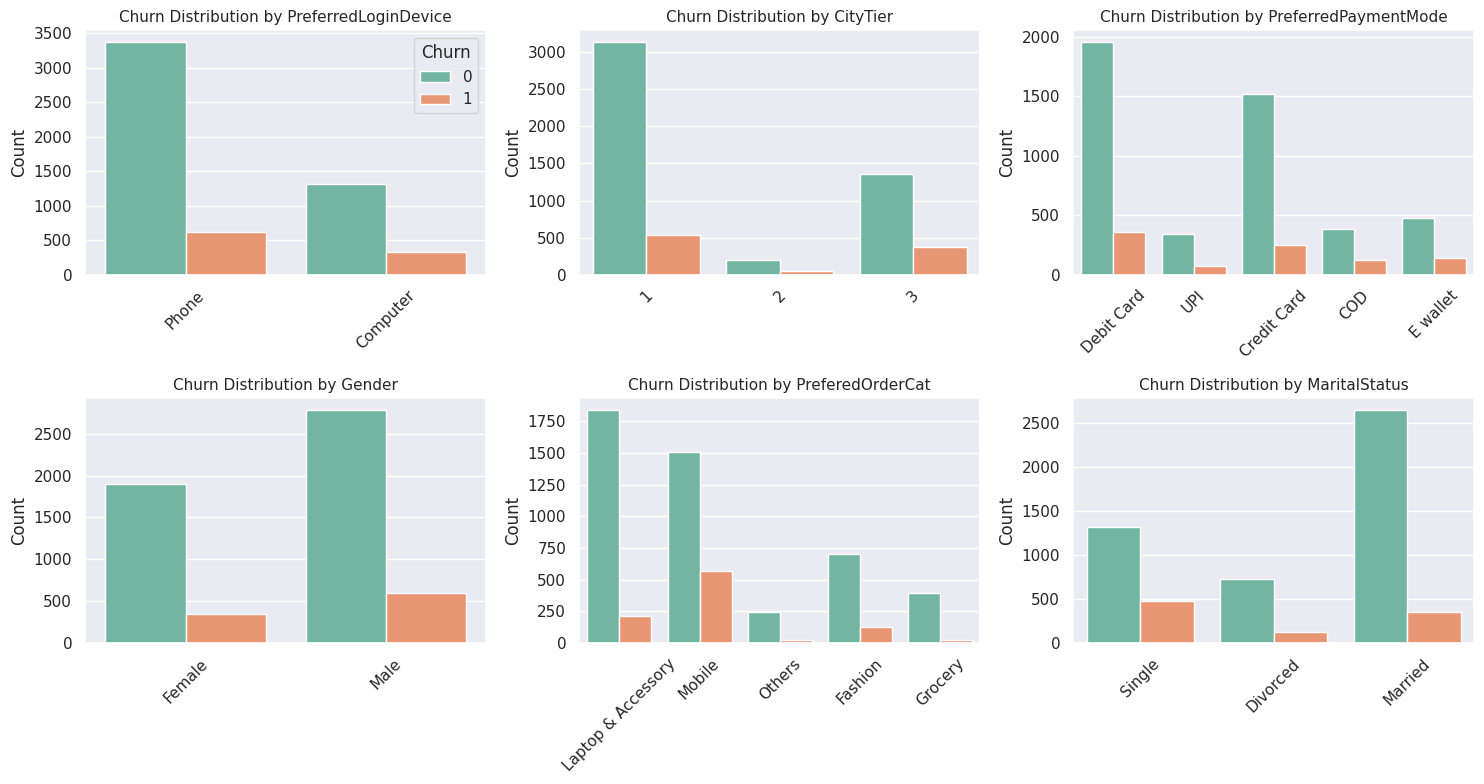

In [ ]:
n_vars = len(cat_vars)
ncols = 3
nrows = math.ceil(n_vars / ncols)
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
axs = axs.flatten()
for i, var in enumerate(cat_vars):
    show_legend = i == 0
    sns.countplot(
        x=var,
        hue="Churn",
        data=df,
        ax=axs[i],
        palette="Set2",
        legend=show_legend,
    )
    axs[i].set_title(f"Churn Distribution by {var}", fontsize=11)
    axs[i].set_xlabel("")
    axs[i].set_ylabel("Count")
    axs[i].tick_params(axis="x", rotation=45)

    if show_legend:
        axs[i].legend(title="Churn", frameon=True)
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

### 1. PreferredLoginDevice
- Majority of customers prefer using **Phone** over **Computer** to access the platform.
- **Computer users show a relatively higher churn proportion**, hinting at lower engagement via desktop.

### 2. CityTier
- **Tier 1 cities dominate the customer base**, with lower churn proportions.
- **Tier 3 customers show a noticeably higher churn rate**, suggesting service/delivery issues there.

### 3. PreferredPaymentMode
- **Debit Card and Credit Card** are the most popular payment methods.
- **COD users show the highest churn rate**, indicating possible trust/convenience issues.
- **UPI and E-wallet users churn the least**, showing a preference for seamless digital payments.

### 4. Gender
- The base is slightly skewed towards **Male** users, and **female customers churn slightly more**.

### 5. PreferedOrderCat
- **Laptop & Accessory and Mobile** are the most preferred categories.
- **Mobile category buyers show higher churn risk**, possibly a one-time-purchase pattern.
- **Grocery and Fashion churn the least**, suggesting more repeat purchases.

### 6. MaritalStatus
- **Married customers are the largest group and churn the least** — family/stability-driven loyalty.
- **Single customers churn more**, and **Divorced customers are a small group with moderate churn**.


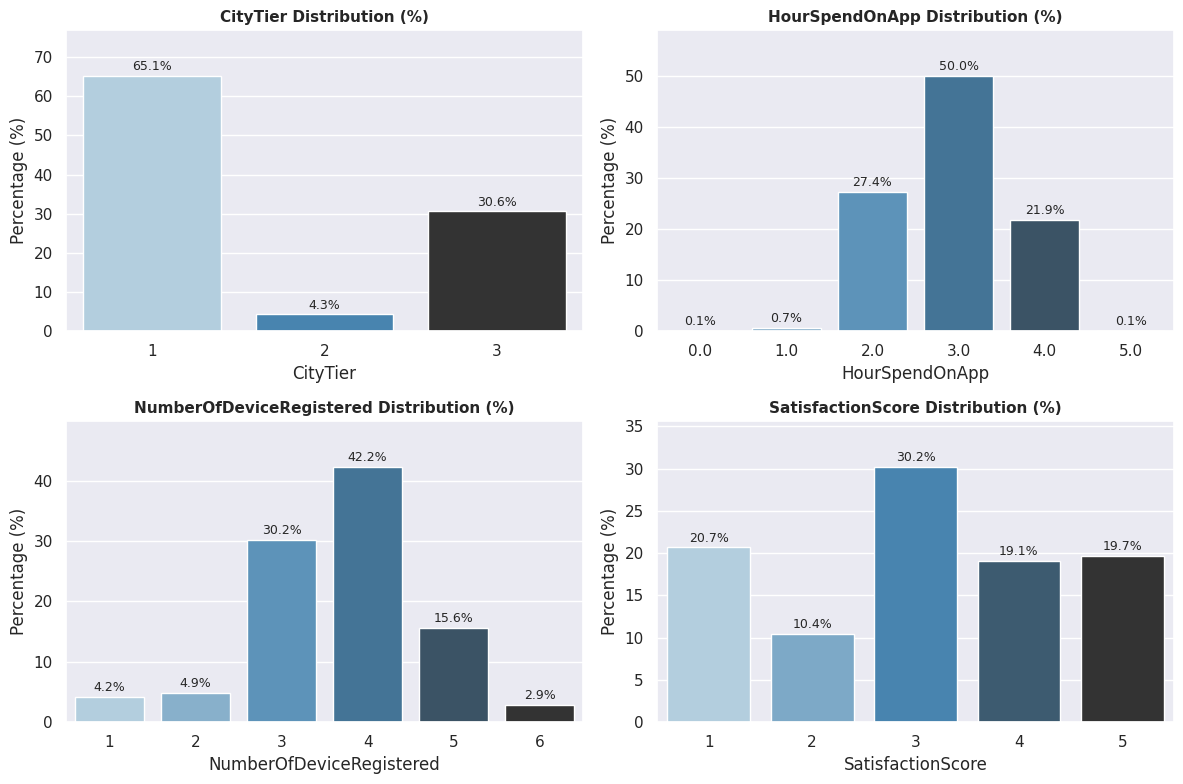

In [ ]:
cat_num = ['CityTier', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore']
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axs = axs.flatten()
for i, var in enumerate(cat_num):
    pct_df = df[var].value_counts(normalize=True).mul(100).sort_index().reset_index()
    pct_df.columns = [var, 'Percentage']
    ax = sns.barplot(
        data=pct_df,
        x=var,
        y='Percentage',
        ax=axs[i],
        palette='Blues_d',
        hue=var,
        legend=False
    )
    axs[i].set_title(f'{var} Distribution (%)', fontsize=11, fontweight='semibold')
    axs[i].set_ylabel('Percentage (%)')
    axs[i].set_xlabel(var)
    axs[i].set_ylim(0, pct_df['Percentage'].max() * 1.18)

    for p in axs[i].patches:
        height = p.get_height()
        if height > 0:
            axs[i].annotate(
                f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9, xytext=(0, 2),
                textcoords='offset points'
            )
fig.tight_layout()
plt.show()

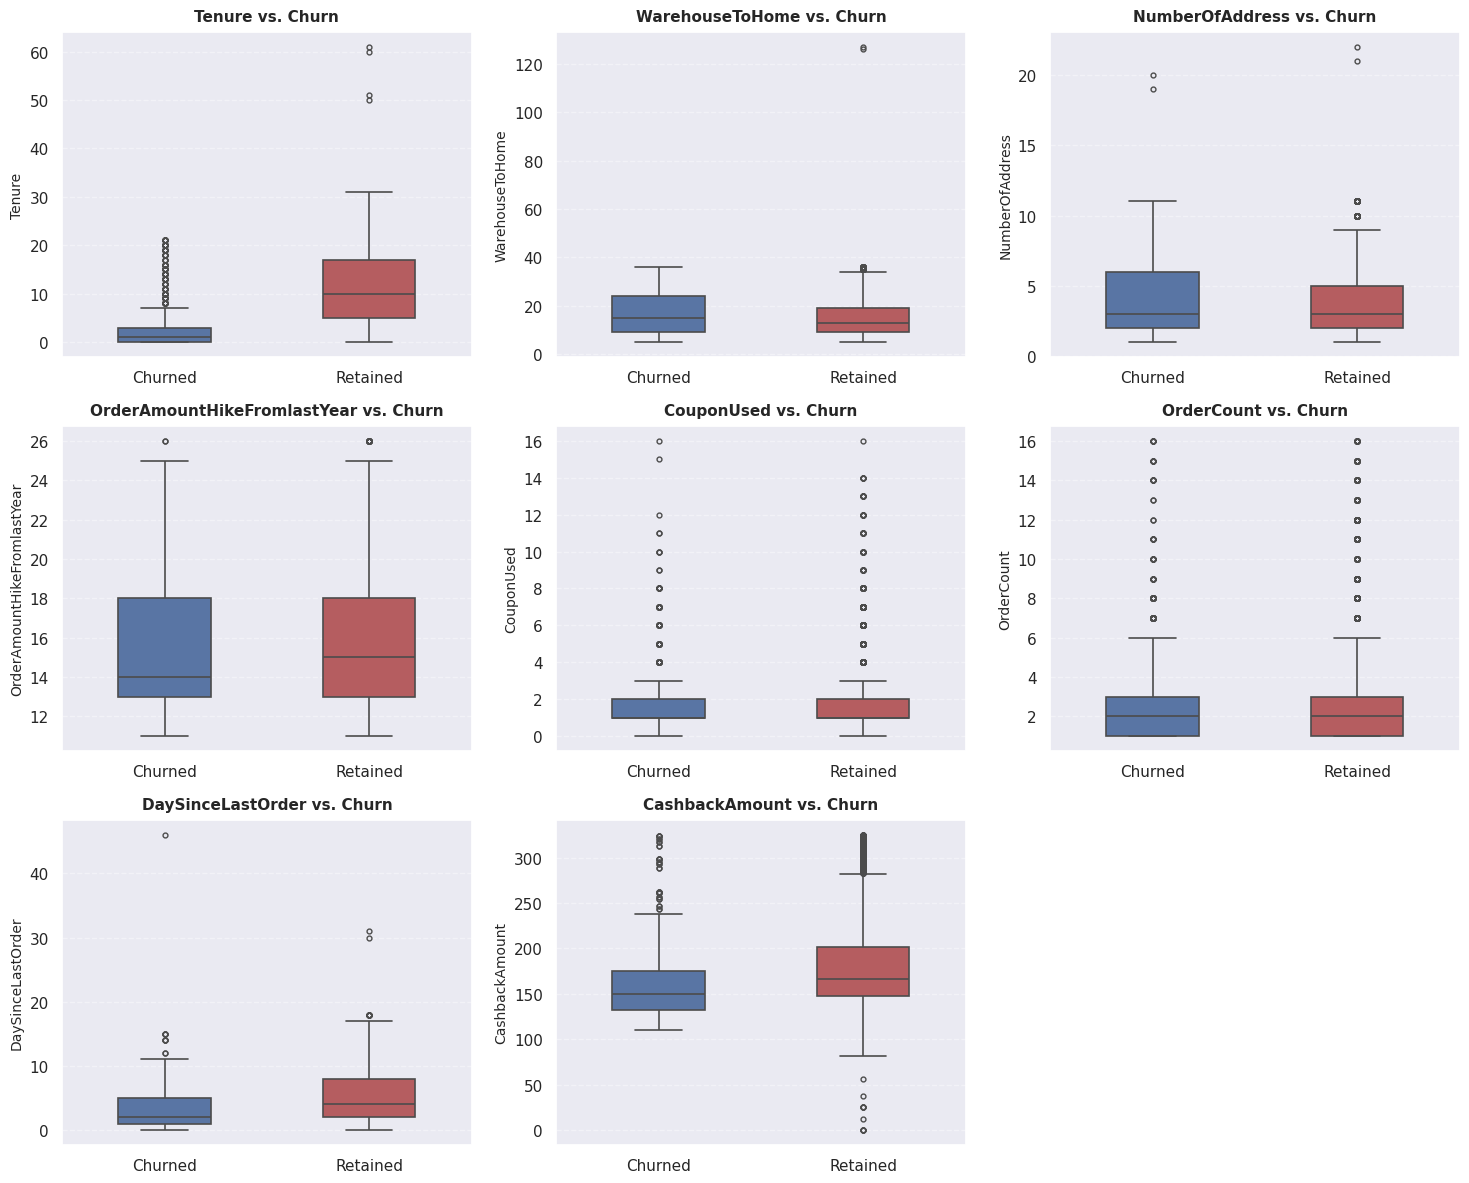

In [ ]:
num_vars = [
    'Tenure', 'WarehouseToHome', 'NumberOfAddress', 'OrderAmountHikeFromlastYear',
    'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'
]
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axs = axs.flatten()
churn_labels = {0: 'Retained', 1: 'Churned'}
plot_df = df.copy()
plot_df['Churn_Label'] = plot_df['Churn'].map(churn_labels)

for i, var in enumerate(num_vars):
    sns.boxplot(
        x='Churn_Label',
        y=var,
        data=plot_df,
        ax=axs[i],
        palette=['#4C72B0', '#C44E52'],
        width=0.45,
        fliersize=3.5,
        linewidth=1.2
    )
    axs[i].set_title(f'{var} vs. Churn', fontsize=11, fontweight='semibold', pad=8)
    axs[i].set_xlabel('')
    axs[i].set_ylabel(var, fontsize=10)
    axs[i].grid(axis='y', linestyle='--', alpha=0.4)
fig.delaxes(axs[8])
fig.tight_layout()
plt.show()

- **`Tenure`**: churned customers show a noticeably lower median tenure.
- **`WarehouseToHome`**: larger warehouse-to-home distances correlate with higher churn.
- **`CashbackAmount`**: retained customers generally receive higher median cashback.
- **`DaySinceLastOrder`**: churned users show shorter recency, often a single-purchase drop-off pattern.

There are also a handful of extreme outliers in `CashbackAmount`, `WarehouseToHome`, `CouponUsed`, `OrderCount` and `DaySinceLastOrder` that are worth capping later.

## Removing duplicate rows

In [ ]:
df[df.duplicated()]

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1347,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
1359,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
1395,1,11.0,Phone,1,6.0,Debit Card,Male,3.0,4,Fashion,3,Single,10,1,13.0,0.0,1.0,0.0,153.81
1456,1,0.0,Computer,1,13.0,Debit Card,Male,3.0,5,Laptop & Accessory,3,Single,2,1,24.0,1.0,1.0,6.0,160.74
1485,1,0.0,Phone,1,15.0,Credit Card,Female,2.0,3,Mobile,5,Single,8,0,22.0,1.0,1.0,4.0,142.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5611,0,12.0,Phone,3,17.0,Debit Card,Female,4.0,4,Laptop & Accessory,1,Married,3,0,12.0,1.0,2.0,10.0,178.43
5613,0,10.0,Phone,3,18.0,E wallet,Female,4.0,5,Laptop & Accessory,1,Married,6,0,14.0,2.0,2.0,1.0,191.52
5620,0,3.0,Phone,1,35.0,Credit Card,Female,4.0,5,Mobile,5,Single,3,0,15.0,1.0,2.0,5.0,162.85
5625,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71


In [ ]:
df.drop_duplicates(inplace=True, keep='first')
df.shape

(5073, 19)

## Train/test split

In [ ]:
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['Churn']
)

print(df_train.shape, df_test.shape)
print('train churn rate:', df_train['Churn'].mean().round(4))
print('test churn rate :', df_test['Churn'].mean().round(4))

(4058, 19) (1015, 19)
train churn rate: 0.1658
test churn rate : 0.1655


## Outlier capping

In [ ]:
cashback_low      = df_train['CashbackAmount'].quantile(0.01)
cashback_high     = df_train['CashbackAmount'].quantile(0.99)
warehouse_high    = df_train['WarehouseToHome'].quantile(0.99)
coupon_high       = df_train['CouponUsed'].quantile(0.95)
ordercount_high   = df_train['OrderCount'].quantile(0.95)
dayslast_high     = df_train['DaySinceLastOrder'].quantile(0.95)

In [ ]:
for d in [df_train, df_test]:
    d['CashbackAmount']  = d['CashbackAmount'].clip(lower=cashback_low, upper=cashback_high)
    d['WarehouseToHome'] = d['WarehouseToHome'].clip(upper=warehouse_high)
    d['CouponUsed']      = d['CouponUsed'].clip(upper=coupon_high)
    d['OrderCount']      = d['OrderCount'].clip(upper=ordercount_high)
    d['DaySinceLastOrder'] = d['DaySinceLastOrder'].clip(upper=dayslast_high)

## Missing value imputation

In [ ]:
df_train.isnull().sum()

,0
Churn,0
Tenure,196
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,172
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,185
NumberOfDeviceRegistered,0
PreferedOrderCat,0


In [ ]:
# central tendency for these two is best represented by the median (skewed distributions)
tenure_median = df_train['Tenure'].median()
hike_median = df_train['OrderAmountHikeFromlastYear'].median()

df_train['Tenure'] = df_train['Tenure'].fillna(tenure_median)
df_test['Tenure'] = df_test['Tenure'].fillna(tenure_median)

df_train['OrderAmountHikeFromlastYear'] = df_train['OrderAmountHikeFromlastYear'].fillna(hike_median)
df_test['OrderAmountHikeFromlastYear'] = df_test['OrderAmountHikeFromlastYear'].fillna(hike_median)

In [ ]:
# these are low-cardinality count columns, mode fits better than median here
coupon_mode = df_train['CouponUsed'].mode()[0]
ordercount_mode = df_train['OrderCount'].mode()[0]

df_train['CouponUsed'] = df_train['CouponUsed'].fillna(coupon_mode)
df_test['CouponUsed'] = df_test['CouponUsed'].fillna(coupon_mode)

df_train['OrderCount'] = df_train['OrderCount'].fillna(ordercount_mode)
df_test['OrderCount'] = df_test['OrderCount'].fillna(ordercount_mode)

The rest (`HourSpendOnApp`, `WarehouseToHome`, `DaySinceLastOrder`) is filled with `KNNImputer`,
since these are related, continuous behavioral signals where a neighbor-based estimate makes more
sense than a single median.

In [ ]:
knn_cols = ['HourSpendOnApp', 'WarehouseToHome', 'DaySinceLastOrder']

knn_scaler = StandardScaler()
train_scaled = knn_scaler.fit_transform(df_train[knn_cols])
test_scaled = knn_scaler.transform(df_test[knn_cols])

knn_imputer = KNNImputer(n_neighbors=5)
train_imputed_scaled = knn_imputer.fit_transform(train_scaled)
test_imputed_scaled = knn_imputer.transform(test_scaled)

df_train[knn_cols] = knn_scaler.inverse_transform(train_imputed_scaled)
df_test[knn_cols] = knn_scaler.inverse_transform(test_imputed_scaled)

In [ ]:
print('remaining NAs — train:', df_train.isnull().sum().sum())
print('remaining NAs — test :', df_test.isnull().sum().sum())

remaining NAs — train: 0
remaining NAs — test : 0


## Correlation / multicollinearity check

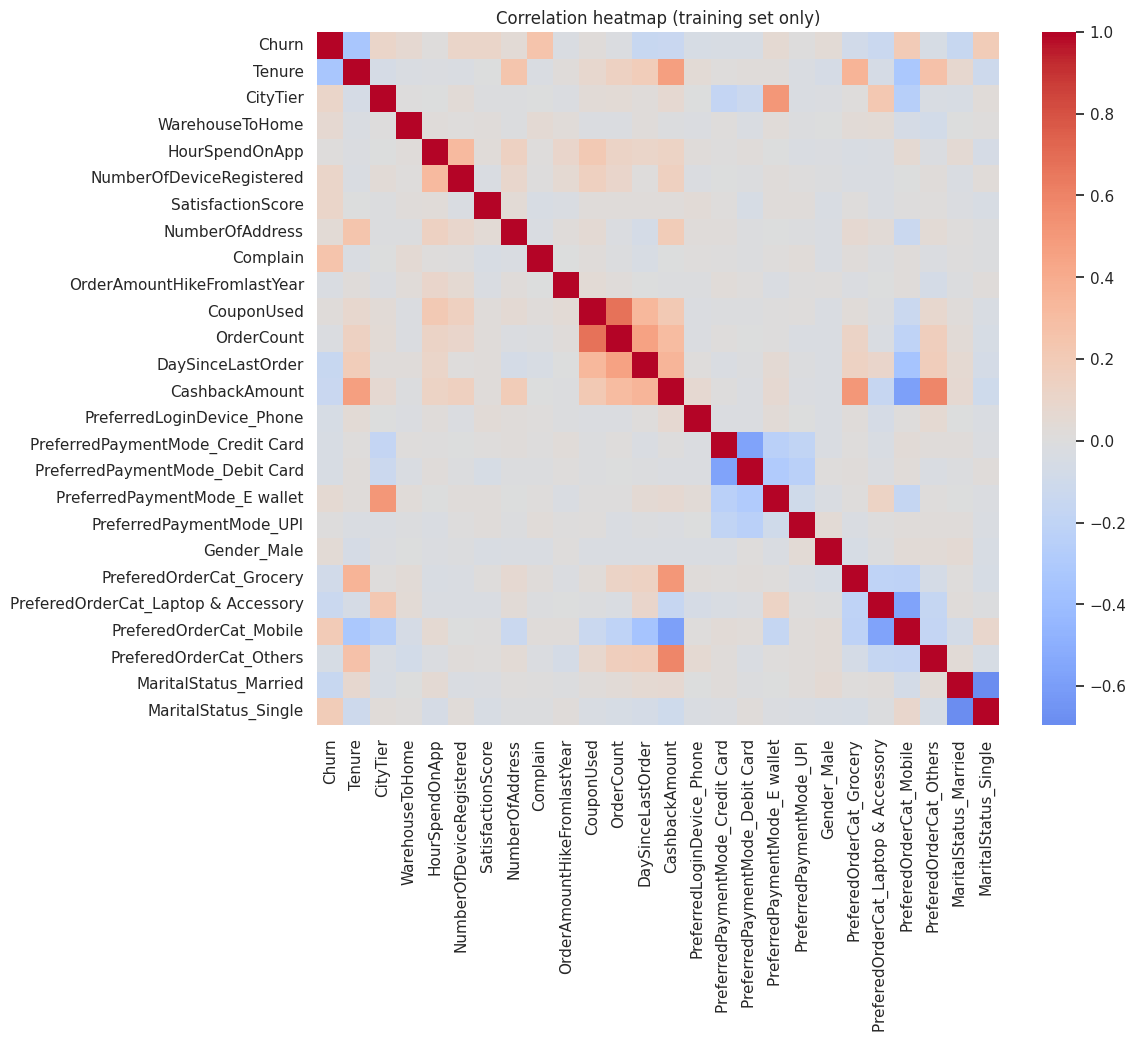

In [ ]:
corr_check = pd.get_dummies(df_train, drop_first=True)  # only for this plot, not saved/reused
plt.figure(figsize=(11, 9))
sns.heatmap(corr_check.corr(), cmap='coolwarm', center=0)
plt.title('Correlation heatmap (training set only)')
plt.show()

## Model comparison

In [ ]:
num = ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
       'SatisfactionScore', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed',
       'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

cat = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat',
       'MaritalStatus', 'Complain']

len(num) + len(cat), df_train.drop(columns='Churn').shape[1]

(18, 18)

### Ordinal Encoding

In [ ]:
ordinal_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num),
        ('cat', OrdinalEncoder(), cat)
    ]
)

In [ ]:
def evaluate_model(model_name, model, preprocessor):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    score = cross_val_score(pipeline, df_train.drop('Churn', axis=1), df_train['Churn'], cv=kfold, scoring='recall')
    return [model_name, score.mean()]

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM' : LGBMClassifier(random_state=42, verbose=-1),
}

In [ ]:
model_output = []
for model_name, model in models.items():
    model_output.append(evaluate_model(model_name, model, ordinal_preprocessor))

model_df_ordinal = pd.DataFrame(model_output, columns=['Model', 'Recall']).sort_values(by='Recall', ascending=False)
model_df_ordinal

,Model,Recall
7,XGBoost,0.851267
8,LightGBM,0.827176
2,Decision Tree,0.818634
3,Random Forest,0.791717
6,Gradient Boosting,0.617609
5,Naive Bayes,0.536458
4,SVM,0.490209
1,KNN,0.486955
0,Logistic Regression,0.423875


### OneHot Encoding

In [ ]:
onehot_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num),
        ('cat', OneHotEncoder(drop='first'), cat)
    ]
)

In [ ]:
model_output_oh = []
for model_name, model in models.items():
    model_output_oh.append(evaluate_model(model_name, model, onehot_preprocessor))

model_df_onehot = pd.DataFrame(model_output_oh, columns=['Model', 'Recall']).sort_values(by='Recall', ascending=False)
model_df_onehot

,Model,Recall
7,XGBoost,0.849291
8,LightGBM,0.810251
2,Decision Tree,0.807580
3,Random Forest,0.772361
5,Naive Bayes,0.740060
6,Gradient Boosting,0.621844
4,SVM,0.531148
0,Logistic Regression,0.517094
1,KNN,0.508372


Linear/distance-based models (`Logistic Regression`, `KNN`, `SVM`) generally do better with
OneHot, since Ordinal Encoding implies a false numeric order between categories like
`PreferredPaymentMode` that those models take literally. Tree-based models don't have that
problem — a tree just picks a threshold to split on, so an arbitrary ordinal code works fine and
keeps the feature space smaller than OneHot would.

Since the best-performing models here are tree ensembles (Random Forest / Gradient Boosting /
XGBoost), we go with **Ordinal Encoding** for the final model — it's simpler, and there's no
distance-metric assumption being violated for a tree.

## Hyperparameter tuning — final model (XGBoost)

`XGBoost` is picked as the final model based on the comparison above.

In [ ]:
param_grid = {
    'model__n_estimators': [200, 250, 300],
    'model__max_depth': [4, 6, 8],
    'model__scale_pos_weight': [3, 5, 7],   # ~ (1 - churn_rate) / churn_rate, to handle class imbalance
    'model__min_child_weight': [1, 3, 5],
    'model__reg_alpha': [0.1, 0.3, 0.5],
}

In [ ]:
final_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num),
        ('cat', OrdinalEncoder(), cat)
    ]
)

xgb_pipeline = Pipeline([
    ('preprocessor', final_preprocessor),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(xgb_pipeline, param_grid=param_grid, cv=kfold, scoring='recall', n_jobs=-1)

In [ ]:
search.fit(df_train.drop('Churn', axis=1), df_train['Churn'])

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Tenure',
                                                                          'CityTier',
                                                                          'WarehouseToHome',
                                                                          'HourSpendOnApp',
                                                                          'NumberOfDeviceRegistered',
                                                                          'SatisfactionScore',
                                                                          'NumberOfAddress',
                                                                          'OrderAmountHikeFromlastYear',
                                                                          'CouponUsed',
                                                                          'OrderCount',
                                                                          'DaySinceLas...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [4, 6, 8],
                         'model__min_child_weight': [1, 3, 5],
                         'model__n_estimators': [200, 250, 300],
                         'model__reg_alpha': [0.1, 0.3, 0.5],
                         'model__scale_pos_weight': [3, 5, 7]},
             scoring='recall')

In [ ]:
search.best_params_

{'model__max_depth': 8,
 'model__min_child_weight': 3,
 'model__n_estimators': 200,
 'model__reg_alpha': 0.3,
 'model__scale_pos_weight': 7}

In [ ]:
search.best_score_

np.float64(0.8754639109697934)

In [ ]:
final_pipe = search.best_estimator_

## Final evaluation on the test set

In [ ]:
y_pred = final_pipe.predict(df_test.drop('Churn', axis=1))

print('Recall   :', recall_score(df_test['Churn'], y_pred))
print('F1       :', f1_score(df_test['Churn'], y_pred))
print('Precision:', precision_score(df_test['Churn'], y_pred))
print('Accuracy :', accuracy_score(df_test['Churn'], y_pred))

Recall   : 0.8928571428571429
F1       : 0.9009009009009009
Precision: 0.9090909090909091
Accuracy : 0.967487684729064


              precision    recall  f1-score   support

           0       0.98      0.98      0.98       847
           1       0.91      0.89      0.90       168

    accuracy                           0.97      1015
   macro avg       0.94      0.94      0.94      1015
weighted avg       0.97      0.97      0.97      1015



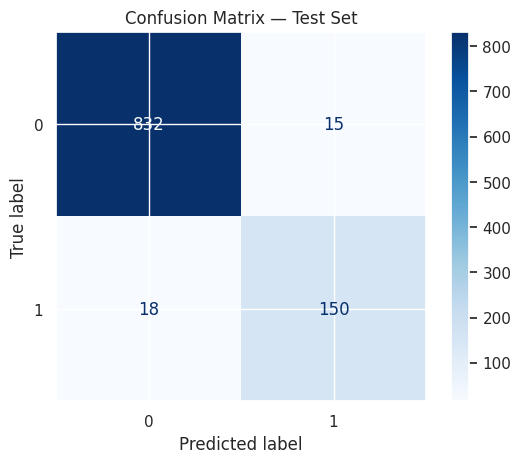

In [ ]:
print(classification_report(df_test['Churn'], y_pred))

ConfusionMatrixDisplay.from_predictions(df_test['Churn'], y_pred, cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.show()

## Feature importance / model interpretation


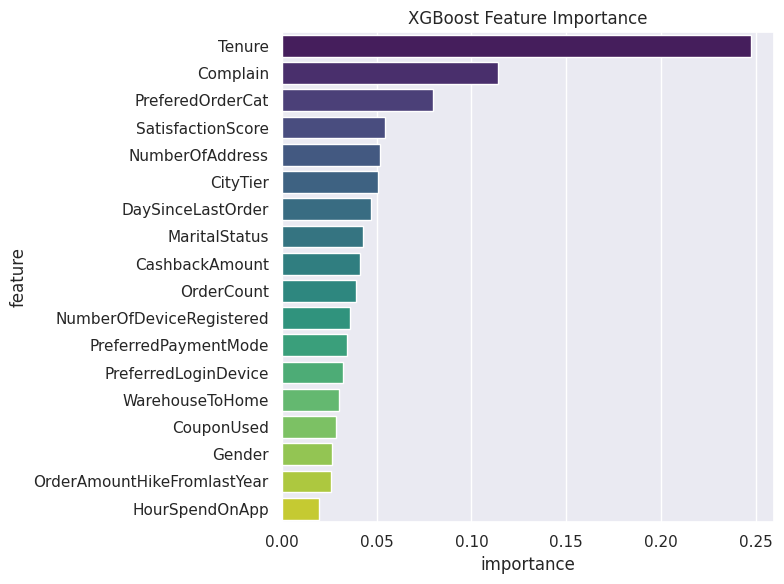

,feature,importance
0,Tenure,0.247272
17,Complain,0.113746
15,PreferedOrderCat,0.079903
5,SatisfactionScore,0.054364
6,NumberOfAddress,0.051529
1,CityTier,0.050808
10,DaySinceLastOrder,0.046762
16,MaritalStatus,0.042835
11,CashbackAmount,0.041013
9,OrderCount,0.039169


In [ ]:
feature_names = num + cat
importances = final_pipe.named_steps['model'].feature_importances_

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis', hue='feature', legend=False)
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

fi_df

**Business takeaways**:
- Low `Tenure` and a recent `Complain` flag are typically the strongest churn signals — newer,
  dissatisfied customers churn the most. Worth a proactive retention outreach in the first few
  months, and after any complaint gets logged.
- `CashbackAmount` and `DaySinceLastOrder` tend to matter a lot too — customers who go quiet or
  receive less cashback are at higher risk.
- `WarehouseToHome` reinforces the EDA finding that delivery distance correlates with churn — could
  point to a logistics/delivery-experience issue worth investigating operationally.


## Export the final pipeline

In [ ]:
with open('pipeline.pkl', 'wb') as f:
    pickle.dump(final_pipe, f)

In [ ]:
# keep the untouched hold-out set around for future reference / reproducibility
df_test.to_csv('test_data.csv', index=False)